In [1]:
import numpy as np
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff

In [2]:
dim = 1
v0 = 1

def infPotFunc(phi):
    return v0

def infPotDerivFunc(phi):
    return 0

infPotentialDerivFuncs = [infPotDerivFunc]

nGrid = 256
upperBound = 1.0
lowerBound = 0.0
upperBoundCond = "Dirichlet"
lowerBoundCond = "Dirichlet"

In [3]:
fpFinDiff = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid],
    [upperBound],
    [lowerBound],
    [upperBoundCond],
    [lowerBoundCond]
)

In [4]:
fpFinDiff

array([[-557.6802382,  278.8401191,    0.       , ...,    0.       ,
           0.       ,    0.       ],
       [ 278.8401191, -557.6802382,  278.8401191, ...,    0.       ,
           0.       ,    0.       ],
       [   0.       ,  278.8401191, -557.6802382, ...,    0.       ,
           0.       ,    0.       ],
       ...,
       [   0.       ,    0.       ,    0.       , ..., -557.6802382,
         278.8401191,    0.       ],
       [   0.       ,    0.       ,    0.       , ...,  278.8401191,
        -557.6802382,  278.8401191],
       [   0.       ,    0.       ,    0.       , ...,    0.       ,
         278.8401191, -557.6802382]])

In [5]:
eigVals, eigVecs = np.linalg.eig(fpFinDiff)
negEigVals = -eigVals
eigVecsSort = eigVecs.T[np.argsort(negEigVals)]
negEigValsSort = np.sort(negEigVals)

In [6]:
import matplotlib.pyplot as plt

In [7]:
nMode = np.arange(1, nGrid + 1)
eigValsTh = [np.pi ** 2 * v0 / (24 * np.pi ** 2) / (upperBound - lowerBound) ** 2 * n ** 2 for n in nMode]

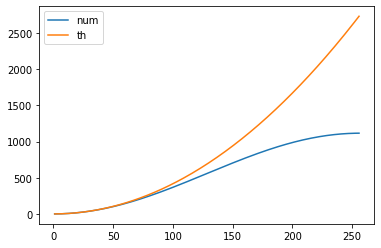

In [8]:
ax = plt.gca()
plt.plot(nMode, negEigValsSort, label = "num")
plt.plot(nMode, eigValsTh, label = "th")
plt.legend()
plt.show()

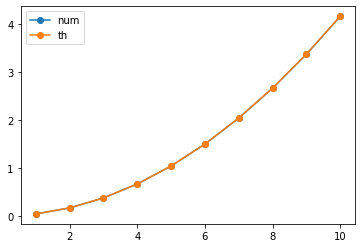

In [9]:
ax = plt.gca()
plt.plot(np.arange(1, 11), negEigValsSort[:10], marker='o', label = "num")
plt.plot(np.arange(1, 11), eigValsTh[:10], marker='o', label = "th")
plt.legend()
plt.show()

考えている$\phi$の領域をちょうど覆うようなGaussianを試行ベクトルに取り、固有ベクトルで展開

In [10]:
grids = np.flip(np.linspace(upperBound, lowerBound, nGrid, endpoint=False))
sigma = (upperBound - lowerBound) / 6.0
trialVec = np.exp(- 0.5 * ((grids - 0.5 * (upperBound + lowerBound)) / sigma) ** 2)
trialVec /= np.linalg.norm(trialVec)

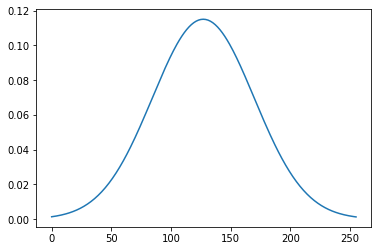

In [11]:
ax = plt.gca()
plt.plot(trialVec)
plt.show()

In [12]:
contriEachEigVec = [np.dot(trialVec, ev) ** 2 for ev in eigVecsSort]

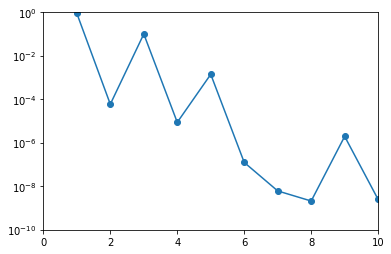

In [15]:
# 各固有ベクトルの寄与度
ax = plt.gca()
plt.plot(nMode, contriEachEigVec, marker='o')
plt.yscale('log')
ax.set_xlim(0, 10)
ax.set_ylim(1e-10, 1)
plt.show()

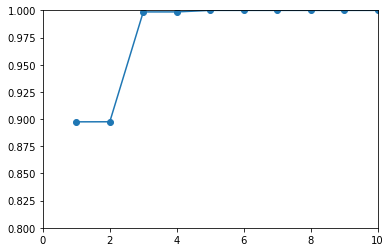

In [14]:
# 各固有ベクトルの寄与度（累積）
ax = plt.gca()
plt.plot(nMode, np.cumsum(contriEachEigVec), marker='o')
ax.set_xlim(0, 10)
ax.set_ylim(0.8, 1)
plt.show()